# Lab 3: Anatomy of a Figure

## Objectives

By the end of this lab, you should be able to:

- Load a dataset into pandas and do a basic first-look inspection
- Explain the difference between a matplotlib `Figure` and an `Axes`
- Name the parts of a chart: title, axis labels, ticks, legend, gridlines, spines
- Build a fully-labeled chart from scratch using matplotlib's object-oriented interface

## Quick recap

This lab assumes you're comfortable with basic Python (variables, functions, NumPy arrays). if any of that feels shaky, work through **Lab 0** first; we won't be re-teaching it here.

One quick reminder: in a Jupyter notebook, only the *last* line of a cell displays automatically. Use `print()` if you want to see more than one thing from a single cell.

## Setup

In [1]:
# !pip install pandas matplotlib palmerpenguins

import pandas as pd
import matplotlib.pyplot as plt
from palmerpenguins import load_penguins

## 1. Loading and inspecting data

Load the `penguins` dataset and preview the first few rows.

In [2]:
# TODO: load penguins, then .head()
penguins = load_penguins()
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


Use `.info()` and `.describe()` to inspect the structure. Which columns are numeric? Which are categorical? Are there missing values?

In [18]:
# TODO: .info()
penguins.info()
penguins.describe()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
 7   year               344 non-null    int64  
dtypes: float64(4), int64(1), str(3)
memory usage: 21.6 KB


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
count,342.000000,342.000000,342.000000,342.000000,344.000000
mean,43.921930,17.151170,200.915205,4201.754386,2008.029070
std,5.459584,1.974793,14.061714,801.954536,0.818356
min,32.100000,13.100000,172.000000,2700.000000,2007.000000
25%,39.225000,15.600000,190.000000,3550.000000,2007.000000
50%,44.450000,17.300000,197.000000,4050.000000,2008.000000
75%,48.500000,18.700000,213.000000,4750.000000,2009.000000
max,59.600000,21.500000,231.000000,6300.000000,2009.000000


In [5]:
# TODO: .describe()
penguins.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
count,342.000000,342.000000,342.000000,342.000000,344.000000
mean,43.921930,17.151170,200.915205,4201.754386,2008.029070
std,5.459584,1.974793,14.061714,801.954536,0.818356
min,32.100000,13.100000,172.000000,2700.000000,2007.000000
25%,39.225000,15.600000,190.000000,3550.000000,2007.000000
50%,44.450000,17.300000,197.000000,4050.000000,2008.000000
75%,48.500000,18.700000,213.000000,4750.000000,2009.000000
max,59.600000,21.500000,231.000000,6300.000000,2009.000000


## 2. The Figure and the Axes

Create an empty `Figure`/`Axes` pair with `plt.subplots()` and display it.

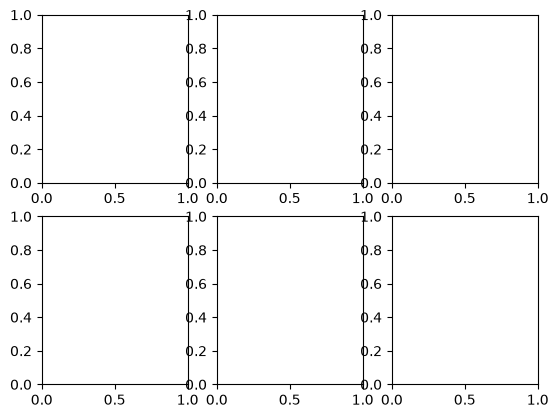

In [12]:
# TODO: fig, ax = plt.subplots(), then plt.show()
fig, ax = plt.subplots(nrows = 2, ncols=3)
plt.show()

In [14]:
ax[0,2]

<Axes: >

## 3. Anatomy, piece by piece

**Step 1:** plot `flipper_length_mm` (x) vs. `body_mass_g` (y) as a scatterplot, with no labels yet, using `ax.scatter()`.

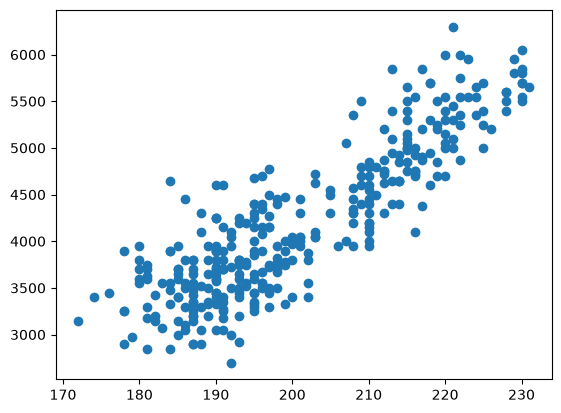

In [15]:
# TODO: bare scatterplot, no labels
fig, ax = plt.subplots()
ax.scatter(penguins["flipper_length_mm"], penguins["body_mass_g"])
plt.show()

**Step 2:** add a title with `ax.set_title()`.

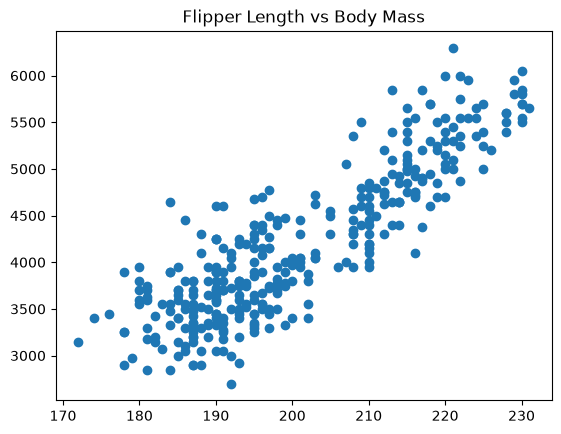

In [17]:
# TODO: same scatterplot + title
fig, ax = plt.subplots()
ax.scatter(penguins["flipper_length_mm"], penguins["body_mass_g"])
ax.set_title("Flipper Length vs Body Mass")
plt.show()


**Step 3:** add x and y axis labels with `ax.set_xlabel()` / `ax.set_ylabel()`, including units.

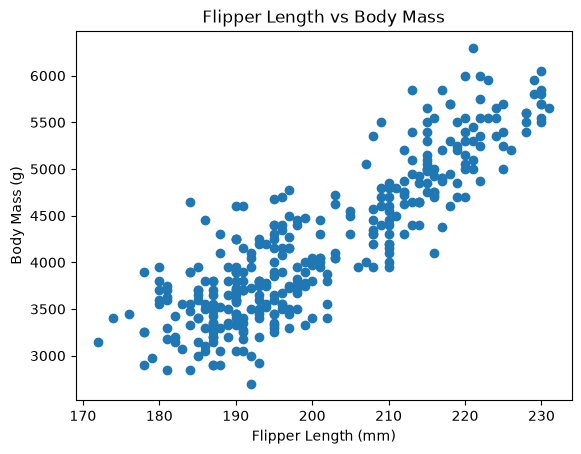

In [19]:
# TODO: same scatterplot + title + axis labels
fig, ax = plt.subplots()
ax.scatter(penguins["flipper_length_mm"], penguins["body_mass_g"])
ax.set_title("Flipper Length vs Body Mass")
ax.set_xlabel("Flipper Length (mm)")
ax.set_ylabel("Body Mass (g)")
plt.show()


**Step 4:** color the points by `species`. Hint: loop over `penguins.groupby("species")`, calling `ax.scatter()` once per group with a `label=` set to the species name, then call `ax.legend()` once, outside the loop.

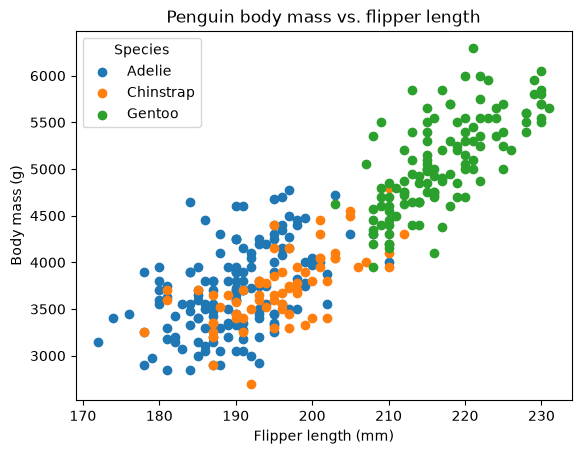

In [22]:
# TODO: scatterplot colored by species, with a legend
fig, ax = plt.subplots()
for species, group in penguins.groupby('species'):
    ax.scatter(group['flipper_length_mm'], group['body_mass_g'], label=species)

ax.set_title("Penguin body mass vs. flipper length")
ax.set_xlabel("Flipper length (mm)")
ax.set_ylabel("Body mass (g)")
ax.legend(title="Species")
plt.show()

**Step 5:** add custom tick marks on the x-axis (`ax.set_xticks([...])`) and gridlines (`ax.grid(True, alpha=0.3)`).

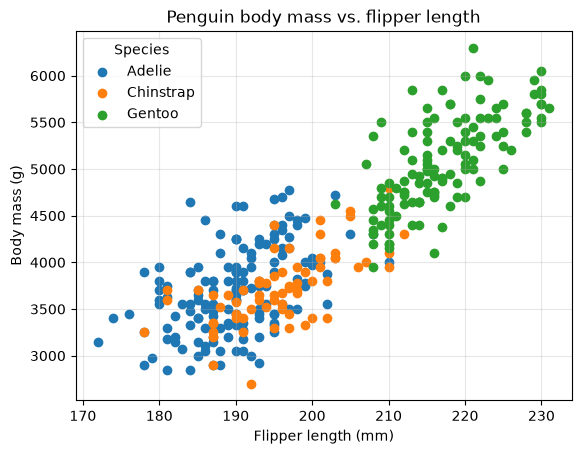

In [24]:
# TODO: same chart + custom xticks + gridlines
fig, ax = plt.subplots()
for species, group in penguins.groupby('species'):
    ax.scatter(group['flipper_length_mm'], group['body_mass_g'], label=species)

ax.set_title("Penguin body mass vs. flipper length")
ax.set_xlabel("Flipper length (mm)")
ax.set_ylabel("Body mass (g)")
ax.legend(title="Species")
ax.set_xticks([170, 180, 190, 200, 210, 220, 230])

ax.grid(True, alpha = 0.3)
plt.show()

**Step 6:** remove the top and right spines (`ax.spines["top"].set_visible(False)`, and the same for `"right"`).

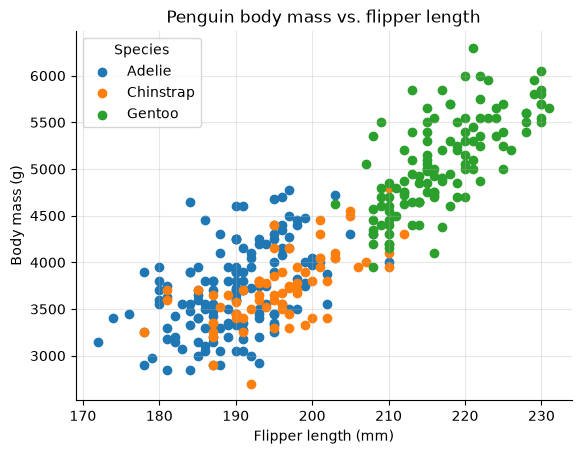

In [30]:
# TODO: same chart + spines removed'
fig, ax = plt.subplots()

for species, group in penguins.groupby("species"):
    ax.scatter(group["flipper_length_mm"], group["body_mass_g"], label=species)

ax.set_title("Penguin body mass vs. flipper length")
ax.set_xlabel("Flipper length (mm)")
ax.set_ylabel("Body mass (g)")
ax.legend(title="Species")

ax.set_xticks([170, 180, 190, 200, 210, 220, 230])
ax.grid(True, alpha=0.3)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()

## 4. Put it together

Combine everything from section 3 into one chart. Also set `figsize=(7, 5)` on `plt.subplots()`, add `alpha=0.7` and `s=40` to your scatter calls, and finish with `plt.tight_layout()` before `plt.show()`.

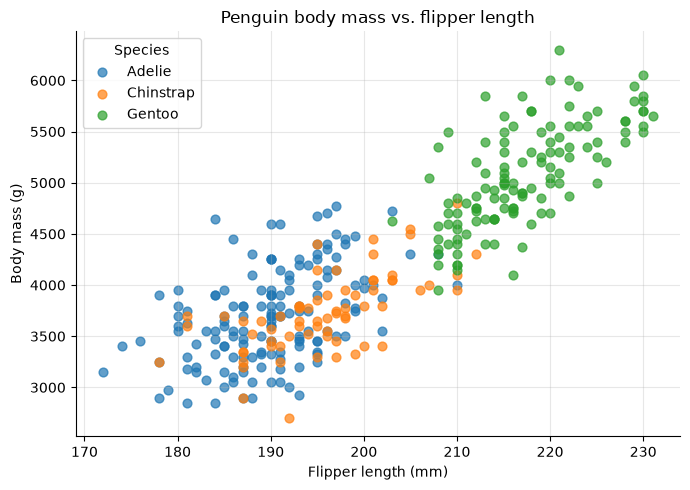

In [32]:
# TODO: the full, final chart

fig, ax = plt.subplots(figsize=(7, 5))

for species, group in penguins.groupby("species"):
    ax.scatter(group["flipper_length_mm"], group["body_mass_g"], label=species,s=40, alpha=0.7)#, s=40 )

ax.set_title("Penguin body mass vs. flipper length")
ax.set_xlabel("Flipper length (mm)")
ax.set_ylabel("Body mass (g)")
ax.legend(title="Species")

ax.set_xticks([170, 180, 190, 200, 210, 220, 230])
ax.grid(True, alpha=0.3)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()



The plot below is an example of using the colormap **viridis** for a continuous variable. You set the colormap using **`cmap="viridis"`** in the plot, and set the attribute being mapped to color using **`c=penguins["bill_length_mm"]`**.

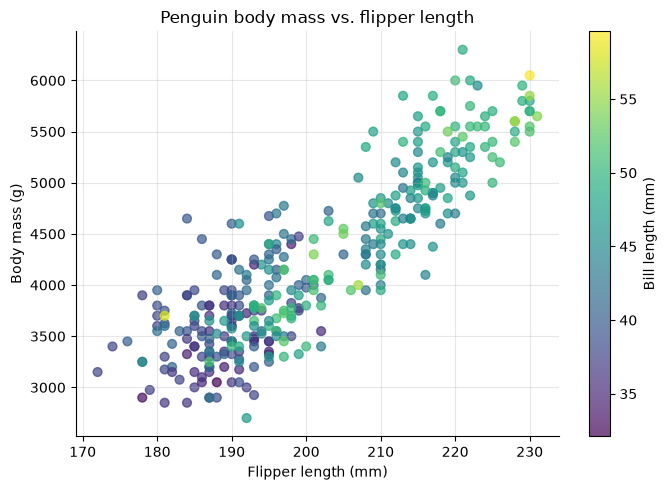

In [28]:
#TODO: the full, final chart with a continuous variable mapped to a colormap

fig, ax = plt.subplots(figsize=(7, 5))

sc = ax.scatter(
    penguins["flipper_length_mm"], penguins["body_mass_g"],
    c=penguins["bill_length_mm"],   # continuous variable
    cmap="viridis", alpha=0.7, s=40
)

ax.set_title("Penguin body mass vs. flipper length")
ax.set_xlabel("Flipper length (mm)")
ax.set_ylabel("Body mass (g)")
# ax.legend(title="Species")
fig.colorbar(sc, ax=ax, label="Bill length (mm)") #don't need label or legend, just colorbar

ax.set_xticks([170, 180, 190, 200, 210, 220, 230])
ax.grid(True, alpha=0.3)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()



# On your own

<div class="alert alert-info">
<b>Your task</b>: In the three steps below, you will reflect on the Visualization Zoo discussion, reflect on using color in a plot, and then make another plot that is different from the ones above and takes into account your reflections. For this, you may use any of the datasets we have used so far in the class: <b>flights, fastfood, volcanoes, or penguins</b>.
</div>

In [ ]:
#if using a different dataset, you may need to change the path to the CSV file. 
fastfood = pd.read_csv("fastfood.csv", index_col=0)
flights = pd.read_csv("flights.csv", index_col=0)
data_src = "https://gist.githubusercontent.com/mattkram/9684863843254402942dfede27af2cb7/raw/2590dd8185b833aacf247c0595edbb07a025a6d7/Smithsonian_VOTW_Holocene_Volcanoes.csv"
volcanoes = pd.read_csv(data_src)


## Part 1

Based on the reading "A Tour of the Visualization Zoo," there was a lot of great discussion. Look at the discussion board and read through some of your peers' comments. Based on one of your peers' comments, reflect on how you might create another effective visualization with this penguins dataset. For example, you could answer a question another student had, and apply your answer to this dataset. You could take into account their analysis and critiques when thinking about how to build a new plot. 

In a few sentences below, you should include:
- The name of the peer you are responding to, and what they said that you found insightful or interesting and want to respond to
- Your response to the question, critique, or insight from them
- How you might apply that question, critique, or insight to a plot made from this dataset, and in light of what you have learned about effective and expressive visualizations. 

For this part 1, you do not need to make the plot; just reflect.

*Write your answer to part 1 here.*

## Part 2

Next, consider how you will use color in your plot. If you will use color for unordered categorical variables, use **hue**. If you will use color for ordered data (quantitative or ordinal), use **hue+lightness** or **hue+saturation** with a color map. 

Answer the following questions in a few sentences:

- How will you use color in a second plot?
- How are you ensuring that your color use is color-blind friendly? 
- How are you ensuring that your color use is perceptually uniform and effective?

*Write your answer to part 2 here*

## Part 3

Finally, build a second, different chart from the `penguins`, `flights`, `volcanoes` or `fastfood` dataset — either a different pair of variables as a scatterplot, or a bar chart of `species` counts (`ax.bar()`), or something else entirely! Include, at minimum: a title, both axis labels, and *at least two* of the other anatomy pieces from this lab (legend, custom ticks, gridlines, or spine removal) — your choice, but pick ones that make sense for your chart. Use `figsize` and `plt.tight_layout()`.

In a markdown cell below your chart:
1. Name which anatomy pieces you added
2. In one sentence each, say what problem each piece of anatomy solves for someone looking at your chart for the first time.
3. For the chart you built, identify **each of the attribute encodings** in the form:
   1. Attribute X (what NOIR type?) --> what channel? (for example,in part 4: flipper length (Q-R) --> horizontal location)
   2. Based on the attribute type, explain why your encoding choice was **both** _expressive_ and _effective_.

In [ ]:
# Your code here

*Your written answer here.*

## Submission

Export this notebook to HTML (or PDF) (`Jupyter: Export to HTML` from the Command Palette, or the "..." menu in the notebook toolbar) and **submit the HTML file or PDF** on Canvas. You should **ALSO submit an ipynb** with all code run and outputs showing. 